# TotalSegmentator Baseline

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## Loading TS results

In [79]:
data0 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch0.csv")
data1 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch1.csv")
data2 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch2.csv")
data3 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/total_seg_output/contrast_phase_results_batch3.csv")


data1
    

,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,file
0,80.03,portal_venous,1.0,77.84,81.19,1.1685,NKI-d23231-00-0145_20070620_kalina99_0212.nii.gz
1,82.57,portal_venous,1.0,81.59,83.29,0.6462,NKI-d23231-00-0145_20071002_kalina99_0213.nii.gz
2,56.70,arterial_late,0.7,49.31,65.95,5.6282,NKI-d23231-00-0145_20080304_kalina99_0215.nii.gz
3,77.27,portal_venous,1.0,76.32,79.26,1.0410,NKI-d23231-00-0145_20080304_kalina99_0216.nii.gz
4,50.59,arterial_late,0.7,44.67,54.72,3.5907,NKI-d23231-00-0145_20090916_kalina99_0217.nii.gz
...,...,...,...,...,...,...,...
1388,76.10,portal_venous,1.0,75.12,78.47,1.2102,NKI-d23231-00-0292_20150407_kalina99_1135.nii.gz
1389,47.73,arterial_late,1.0,43.38,52.07,3.1476,NKI-d23231-00-0292_20150407_kalina99_1136.nii.gz
1390,77.90,portal_venous,1.0,76.26,80.24,1.3613,NKI-d23231-00-0292_20151026_kalina99_1137.nii.gz
1391,48.78,arterial_late,1.0,43.92,52.95,3.1085,NKI-d23231-00-0292_20151026_kalina99_1138.nii.gz


In [80]:
ts_data = pd.concat([data0, data1, data2, data3])
ts_data   # Error processing /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0818_20190322_kalina99_5441.nii.gz: Command '['totalseg_get_phase', '-i', np.str_('/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0818_20190322_kalina99_5441.nii.gz'), '-o', '/projects/net_contrast_classification/contrast_phase/total_seg_output/NKI-d23231-00-0818_20190322_kalina99_5441_phase.json']' returned non-zero exit status 1.

,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,file
0,62.02,portal_venous,1.0,56.91,66.18,3.0706,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz
1,78.87,portal_venous,1.0,76.97,80.38,1.1980,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz
2,69.99,portal_venous,1.0,67.83,72.74,1.7276,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz
3,74.84,portal_venous,1.0,66.55,82.59,5.8700,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz
4,73.99,portal_venous,1.0,73.19,75.08,0.7242,NKI-d23231-00-0049_20090212_kalina01_0005.nii.gz
...,...,...,...,...,...,...,...
1387,80.39,portal_venous,1.0,78.27,82.66,1.4937,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz
1388,59.19,arterial_late,0.7,56.14,61.54,1.8509,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz
1389,77.28,portal_venous,1.0,74.66,78.94,1.6271,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz
1390,63.08,portal_venous,1.0,60.32,64.76,1.5287,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz


In [81]:
from pathlib import PureWindowsPath
import os

data = pd.read_csv("cleaned_data.csv")
data["file0"] = data["file"]
data["file"] = data["NiiFile"].apply(lambda x: PureWindowsPath(x).name)
data

,SubjectKeyRadiology,ExamDate,SegmentationBatch,NiiFile,SegNiiFile,file,is_liver_imaged,contrast,phase_timing,is_lesionfree,...,ExposureTime,XRayTubeCurrent,XRayExposure,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,slice_thickness,DICOM_phase,file0
0,NKI-d23231-00-0063,2012-04-16,kalina01_0000,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,Partially,Arterial,Too Early,No,...,0.5,150,75,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.0,Arterial,NET_0000_0000.nii.gz
1,NKI-d23231-00-0036,2014-02-18,kalina01_0002,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,Yes,Portal,Just Right,Yes,...,0.5,75,37,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.0,NaN,NET_0002_0000.nii.gz
2,NKI-d23231-00-0071,2013-09-24,kalina01_0003,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,Yes,Arterial,Just Right,Yes,...,0.5,168,84,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.5,NaN,NET_0003_0000.nii.gz
3,NKI-d23231-00-0077,2014-12-22,kalina01_0004,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,Yes,Portal,Just Right,No,...,0.5,119,74,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.5,Portal,NET_0004_0000.nii.gz
4,NKI-d23231-00-0049,2009-02-12,kalina01_0005,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0049_20090212_kalina01_0005.nii.gz,Yes,Portal,Just Right,Yes,...,0.5,280,140,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.5,Portal,NET_0005_0000.nii.gz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5442,NKI-d23231-00-0888,2022-04-20,kalina99_5827,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,Yes,Portal,Just Right,No,...,0.5,158,98,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.5,Portal,NET_5827_0000.nii.gz
5443,NKI-d23231-00-0888,2023-04-24,kalina99_5828,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,Yes,Arterial,Just Right,Yes,...,0.5,316,175,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.0,Late arterial,NET_5828_0000.nii.gz
5444,NKI-d23231-00-0888,2023-04-24,kalina99_5829,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,Yes,Portal,Just Right,No,...,0.5,304,168,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.0,NaN,NET_5829_0000.nii.gz
5445,NKI-d23231-00-0888,2023-08-01,kalina99_5830,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,Yes,Arterial,Just Right,Yes,...,0.5,167,92,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,1.0,Late arterial,NET_5830_0000.nii.gz


In [82]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5447 entries, 0 to 5446
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SubjectKeyRadiology                 5447 non-null   str    
 1   ExamDate                            5447 non-null   str    
 2   SegmentationBatch                   5447 non-null   str    
 3   NiiFile                             5447 non-null   str    
 4   SegNiiFile                          5447 non-null   str    
 5   file                                5447 non-null   str    
 6   is_liver_imaged                     5447 non-null   str    
 7   contrast                            5447 non-null   str    
 8   phase_timing                        5447 non-null   str    
 9   is_lesionfree                       5447 non-null   str    
 10  ai_segmentation_quality             3495 non-null   float64
 11  manual_segmentation_confidence      3495 non-null   fl

In [83]:
merged_data = pd.merge(data, ts_data, on=["file"])

print("True contrast labels:\n", merged_data["contrast"].value_counts())
print("\n")
print("True timing labels:\n",merged_data["phase_timing"].value_counts())
print('\n')
print("TS labels:\n",merged_data["phase"].value_counts())


True contrast labels:
 contrast
Portal          3281
Arterial        2123
Non-contrast      42
Name: count, dtype: int64


True timing labels:
 phase_timing
Just Right      4502
Too Early        759
Too Late         148
Non-contrast      37
Name: count, dtype: int64


TS labels:
 phase
portal_venous     3922
arterial_late     1482
native              30
arterial_early      12
Name: count, dtype: int64


In [84]:
# Create TS phase
merged_data["TS_contrast"] = merged_data["phase"].apply(lambda x: x.split("_")[0].capitalize() if "_" in x else 'Non-contrast')

# merged_data["TS_timing"] = merged_data["phase"].apply(lambda x: x.split("_")[1].capitalize() if "_" in x else "Non-contrast")
# merged_data["TS_timing"] = merged_data["TS_timing"].apply(lambda x: "Just Right" if x == 'Venous' else x)
# merged_data["TS_timing"] = merged_data["TS_timing"].apply(lambda x: "Too Early" if x == 'Early' else x)
# merged_data["TS_timing"] = merged_data["TS_timing"].apply(lambda x: "Too Late" if x == 'Late' else x)


# merged_data.loc[merged_data["contrast"] == "Non-contrast","phase_timing"] = "Non-contrast"
# mask = (
#     merged_data["contrast"] != "Non-contrast"
# ) & (
#     merged_data["phase_timing"] == "Non-contrast"
# )

# merged_data.loc[mask, "phase_timing"] = "Just Right"

print('After renaming:')
print("True labels:\n", merged_data["contrast"].value_counts())
print("\n")
print("TS labels:\n",merged_data["TS_contrast"].value_counts()) # Early AP and Late AP from TS are merged in AP

After renaming:
True labels:
 contrast
Portal          3281
Arterial        2123
Non-contrast      42
Name: count, dtype: int64


TS labels:
 TS_contrast
Portal          3922
Arterial        1494
Non-contrast      30
Name: count, dtype: int64


## Arterial vs. Portal vs. NC

In [85]:
merged_data.head(5)

,SubjectKeyRadiology,ExamDate,SegmentationBatch,NiiFile,SegNiiFile,file,is_liver_imaged,contrast,phase_timing,is_lesionfree,...,slice_thickness,DICOM_phase,file0,pi_time,phase,probability,pi_time_min,pi_time_max,stddev,TS_contrast
0,NKI-d23231-00-0063,2012-04-16,kalina01_0000,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,Partially,Arterial,Too Early,No,...,1.0,Arterial,NET_0000_0000.nii.gz,62.02,portal_venous,1.0,56.91,66.18,3.0706,Portal
1,NKI-d23231-00-0036,2014-02-18,kalina01_0002,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,Yes,Portal,Just Right,Yes,...,1.0,NaN,NET_0002_0000.nii.gz,78.87,portal_venous,1.0,76.97,80.38,1.1980,Portal
2,NKI-d23231-00-0071,2013-09-24,kalina01_0003,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,Yes,Arterial,Just Right,Yes,...,1.5,NaN,NET_0003_0000.nii.gz,69.99,portal_venous,1.0,67.83,72.74,1.7276,Portal
3,NKI-d23231-00-0077,2014-12-22,kalina01_0004,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,Yes,Portal,Just Right,No,...,1.5,Portal,NET_0004_0000.nii.gz,74.84,portal_venous,1.0,66.55,82.59,5.8700,Portal
4,NKI-d23231-00-0049,2009-02-12,kalina01_0005,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,NKI-d23231-00-0049_20090212_kalina01_0005.nii.gz,Yes,Portal,Just Right,Yes,...,1.5,Portal,NET_0005_0000.nii.gz,73.99,portal_venous,1.0,73.19,75.08,0.7242,Portal


In [86]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(merged_data["contrast"])
y_pred = le.fit_transform(merged_data['TS_contrast'])

print('Contrast classification accuracy:', round(accuracy_score(y_true, y_pred),3))
print("Classification report:\n", classification_report(y_true, y_pred, target_names=le.classes_))

Contrast classification accuracy: 0.874
Classification report:
               precision    recall  f1-score   support

    Arterial       0.99      0.69      0.81      2123
Non-contrast       0.93      0.67      0.78        42
      Portal       0.83      0.99      0.91      3281

    accuracy                           0.87      5446
   macro avg       0.92      0.78      0.83      5446
weighted avg       0.89      0.87      0.87      5446



In [87]:
misclassified = merged_data[
    merged_data['contrast'] != merged_data['TS_contrast']
]
print('Number of misclassifications:', len(misclassified))
print("Confusion matrix:")
pd.crosstab(
    merged_data['contrast'],
    merged_data['TS_contrast'],
    margins=True
)

Number of misclassifications: 684
Confusion matrix:


TS_contrast,Arterial,Non-contrast,Portal,All
contrast,,,,
Arterial,1473,0,650,2123
Non-contrast,3,28,11,42
Portal,18,2,3261,3281
All,1494,30,3922,5446


In [88]:
# 20 entries where DICOM contrast = TS contrast but radiologists put different label

misclass_correct_dicom = misclassified[
                (misclassified['DICOM_phase'] == misclassified['TS_contrast']) & 
                (merged_data['DICOM_phase'].notna())
                ][['file', 'contrast','ProtocolName', 'DICOM_phase', 'TS_contrast']]
print(f'TS predicted the correct DICOM label for {len(misclass_correct_dicom)}/{len(misclassified)} entries.')

misclass_correct_dicom

TS predicted the correct DICOM label for 20/684 entries.


/tmp/ipykernel_1817636/4025440245.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclass_correct_dicom = misclassified[


,file,contrast,ProtocolName,DICOM_phase,TS_contrast
281,NKI-d23231-00-0007_20100517_kalina09_0043.nii.gz,Arterial,Abdomen V 2mm,Portal,Portal
1053,NKI-d23231-00-0152_20180116_giovanni01_0231.ni...,Portal,Abdomen A 1.5 B25f,Arterial,Arterial
1702,NKI-d23231-00-0348_20131112_kalina01_0124.nii.gz,Portal,ABDOMEN A 1.0 FC01,Arterial,Arterial
1719,NKI-d23231-00-0385_20171227_kalina01_0153.nii.gz,Non-contrast,Abdomen V 1.5 B25f,Portal,Portal
1964,NKI-d23231-00-0873_20230822_kalina01_0511.nii.gz,Arterial,ABD PV Body 1.0 CE ABD PV,Portal,Portal
2160,NKI-d23231-00-0223_20210618_kalina99_0292.nii.gz,Arterial,Abdomen V 1.5 B25f,Portal,Portal
2824,NKI-d23231-00-0306_20160415_kalina99_1333.nii.gz,Portal,ABDOMEN A 1.0 FC01,Arterial,Arterial
2857,NKI-d23231-00-0308_20181122_kalina99_1389.nii.gz,Portal,Abdomen A 1.5 B25f,Arterial,Arterial
3000,NKI-d23231-00-0332_20080502_kalina99_1679.nii.gz,Arterial,Abdomen V 1.5 B25f,Portal,Portal
3340,NKI-d23231-00-0382_20160203_kalina99_2225.nii.gz,Arterial,Abd-Veneus 3.0 B40f,Portal,Portal


In [89]:
misclass_dicom = misclassified[
    (misclassified['TS_contrast'] != misclassified['DICOM_phase']) |
    (misclassified['DICOM_phase'].isna())
][['file', 'contrast','ProtocolName', 'DICOM_phase', 'TS_contrast']]

print('Number of entries where both DICOM and radiologists\' contrast != TS contrast:', len(misclass_dicom))
misclass_dicom.tail(5)

Number of entries where both DICOM and radiologists' contrast != TS contrast: 664


,file,contrast,ProtocolName,DICOM_phase,TS_contrast
5395,NKI-d23231-00-0875_20230802_kalina99_5760.nii.gz,Arterial,Abdomen Art 1.0 Br36 3,Arterial,Portal
5405,NKI-d23231-00-0879_20210929_kalina99_5775.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
5426,NKI-d23231-00-0882_20220829_kalina99_5801.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
5433,NKI-d23231-00-0887_20210825_kalina99_5811.nii.gz,Arterial,Abdomen A 1.5 B25f,Arterial,Portal
5444,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal


In [90]:
print(f'{len(misclass_dicom[misclass_dicom.DICOM_phase == 'Late arterial'])}/{len(misclass_dicom)} entries have a \'Late arterial\' true phase.')
misclass_dicom[misclass_dicom.DICOM_phase == 'Late arterial']

77/664 entries have a 'Late arterial' true phase.


,file,contrast,ProtocolName,DICOM_phase,TS_contrast
72,NKI-d23231-00-0005_20221017_kalina02_0055.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
164,NKI-d23231-00-0033_20220817_kalina05_0052.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
454,NKI-d23231-00-0059_20230615_kalina12_0020.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
530,NKI-d23231-00-0039_20230130_kalina99_0079.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
559,NKI-d23231-00-0043_20180719_kalina99_0123.nii.gz,Arterial,Abd laat-art 1.0 I26f 2,Late arterial,Portal
...,...,...,...,...,...
5360,NKI-d23231-00-0865_20220623_kalina99_5717.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
5373,NKI-d23231-00-0868_20230322_kalina99_5734.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
5405,NKI-d23231-00-0879_20210929_kalina99_5775.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
5426,NKI-d23231-00-0882_20220829_kalina99_5801.nii.gz,Arterial,Abd laat-art 1.0 Bv38 2,Late arterial,Portal


In [91]:
# 76 of 77 entries where DICOM = late arterial were classified as portal by TS and as arterial by radiologists
print(misclass_dicom[misclass_dicom.DICOM_phase == 'Late arterial']['TS_contrast'].value_counts())
print('\n')
print(misclass_dicom[misclass_dicom.DICOM_phase == 'Late arterial']['contrast'].value_counts())

TS_contrast
Portal      76
Arterial     1
Name: count, dtype: int64


contrast
Arterial    76
Portal       1
Name: count, dtype: int64


In [92]:
misclass_dicom[(misclass_dicom.DICOM_phase == 'Late arterial') & (misclass_dicom.contrast == 'Portal')]

,file,contrast,ProtocolName,DICOM_phase,TS_contrast
1014,NKI-d23231-00-0146_20190502_giovanni01_0179.ni...,Portal,Abd laat-art 1.0 I26f 2,Late arterial,Arterial


In [22]:
misclassified.is_liver_imaged.value_counts()

is_liver_imaged
Yes          646
Partially     30
0              8
Name: count, dtype: int64

In [93]:
misclassified = misclassified[misclassified.is_liver_imaged != '0']
misclassified.is_liver_imaged.value_counts()

is_liver_imaged
Yes          646
Partially     30
Name: count, dtype: int64

In [ ]:
from monai.transforms import LoadImage, EnsureChannelFirst


folder_path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"


def data_load(folder_dir, data, group_col = 'contrast', num = 3, channel_first = True, load = True):
    samples = (data.groupby(group_col)
           .apply(lambda x: x.sample(n=min(num, len(x)), random_state=42))
           .reset_index()
                   )
    
    images = [] 
    
    if load == True:  
        loader = LoadImage(image_only=True)
        files = list(samples['file'])
        phases = list(samples['contrast'])
        for file in files:
            file_dir = os.path.join(folder_dir, PureWindowsPath(file).name)
            ct = loader(file_dir)
            if channel_first:
                ct = EnsureChannelFirst()(ct)

            ct = ct.numpy()
            images.append(ct)

    return samples, phases, images


samples, phases, misclass_images = data_load(folder_path, misclassified)

In [35]:
samples

,contrast,level_1,file,ProtocolName,DICOM_phase,TS_contrast
0,Arterial,5360,NKI-d23231-00-0865_20220623_kalina99_5717.nii.gz,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
1,Arterial,3245,NKI-d23231-00-0359_20230920_kalina99_2074.nii.gz,Abd laat-art 1.0 Bv38 2,Late arterial,Portal
2,Arterial,4244,NKI-d23231-00-0540_20150623_kalina99_3843.nii.gz,ABDOMEN A 1.0 FC01,Arterial,Portal
3,Non-contrast,2100,NKI-d23231-00-0218_20160420_kalina99_0212.nii.gz,ThxAbd 1.5 B25f,NaN,Portal
4,Non-contrast,918,NKI-d23231-00-0162_20050214_giovanni01_0045.ni...,Abdomen OB 1.5 B30f,NaN,Portal
5,Non-contrast,1637,NKI-d23231-00-0223_20180516_kalina01_0020.nii.gz,Body 1.0 CE Vol.,NaN,Portal
6,Portal,4551,NKI-d23231-00-0653_20201014_kalina99_4513.nii.gz,ThorAbd 1.0 Bv38 2,NaN,Arterial
7,Portal,4490,NKI-d23231-00-0615_20190910_kalina99_4359.nii.gz,Body 1.0 CE Vol.,NaN,Arterial
8,Portal,243,NKI-d23231-00-0024_20210423_kalina08_0039.nii.gz,Body 1.0 CE Vol.,NaN,Arterial


In [39]:
misclass_images[4].shape

(1, 512, 512, 75)

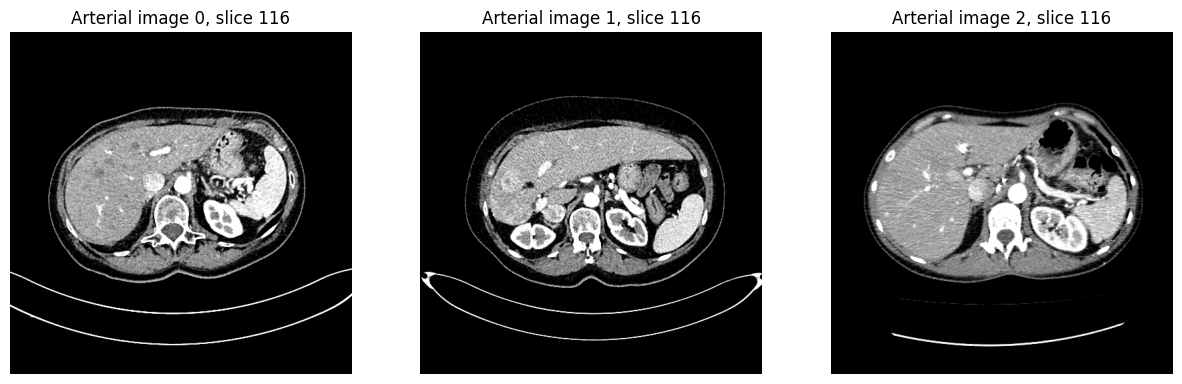

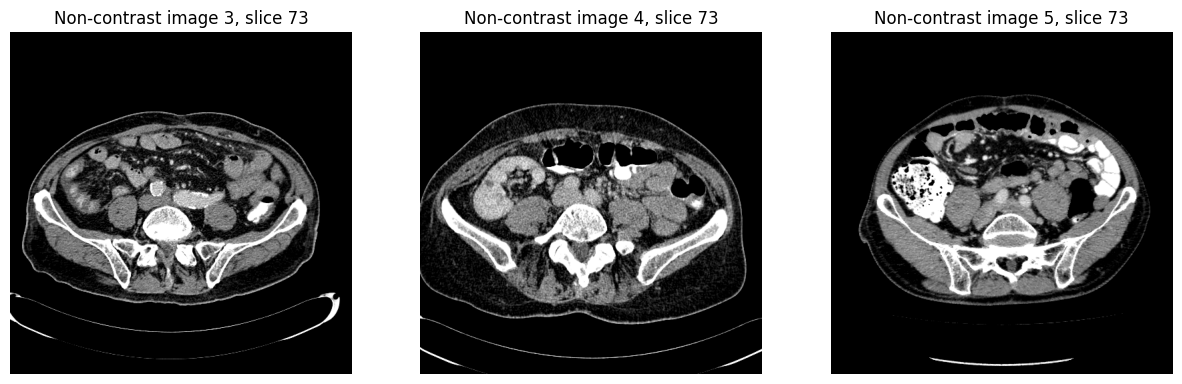

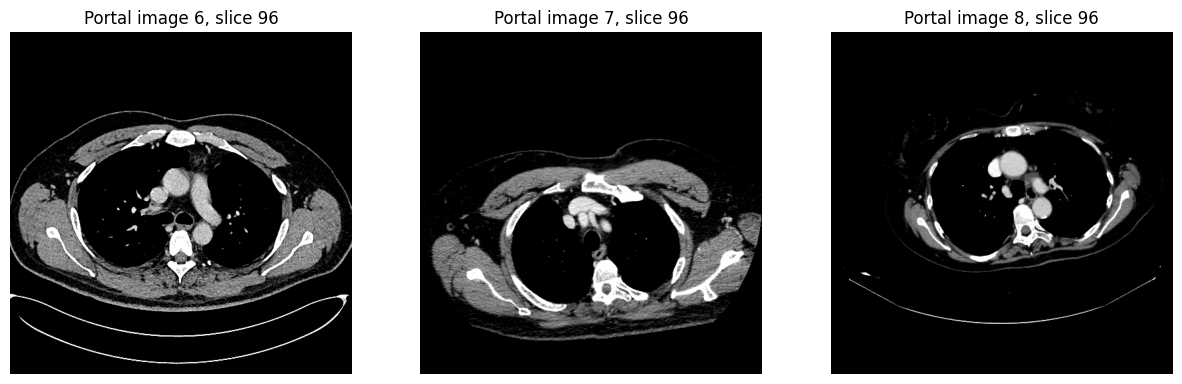

In [ ]:
def show_slices_per_class(images, center=50, width=300):

    def window_ct(img, center, width):
        low = center - width/2
        high = center + width/2
        return img.clip(low, high)


    class_ranges = {
        "Arterial": range(0, 3),
        "Non-contrast": range(3, 6),
        "Portal": range(6, 9)
    }

    for cls_name, indices in class_ranges.items():

        if cls_name == 'Portal':
            z = 50
        else:
            z = int(np.mean([images[i].shape[3] for i in indices]))- 30

        plt.figure(figsize=(15,5))
        for j, i in enumerate(indices):
            img = images[i][0, :, :, z]
            plt.subplot(1, 3, j+1)
            plt.imshow(np.rot90(window_ct(img, center, width),k=1), cmap="gray")
            plt.title(f"{cls_name} image {i}, slice {z}")
            plt.axis("off")
        plt.show()

show_slices_per_class(misclass_images)

## Phase + Timing Classification Results

In [ ]:
# merged_data.loc[merged_data["contrast"] == "Portal","phase_timing"] = "Just Right"

# merged_data["phase_timing_combined"] = (merged_data["contrast"].str.cat(merged_data["phase_timing"], sep=" "))
# merged_data["TS_phase_timing_combined"] = (merged_data["TS_contrast"].str.cat(merged_data["TS_timing"], sep=" "))

# print(merged_data["phase_timing_combined"].value_counts())
# print("\n")
# print(merged_data["TS_phase_timing_combined"].value_counts())


# contrast_correct = merged_data[merged_data["contrast"] == merged_data["TS_contrast"]].copy()

# y_true = le.fit_transform(contrast_correct["phase_timing"])
# y_pred = le.fit_transform(contrast_correct['TS_timing'])

# print('Timing classification accuracy:', round(accuracy_score(y_true, y_pred),3))
# print("Classification report:\n", classification_report(y_true, y_pred, target_names=le.classes_))

# print("Confusion matrix:")
# pd.crosstab(
#     contrast_correct["phase_timing"],
#     contrast_correct['TS_timing'],
#     margins=True
# )

phase_timing_combined
Portal Just Right            3133
Arterial Just Right          1365
Arterial Too Early            661
Arterial Too Late              97
Portal Too Early               97
Portal Too Late                51
Non-contrast Non-contrast      42
Name: count, dtype: int64


TS_phase_timing_combined
Portal Just Right            3922
Arterial Too Late            1482
Non-contrast Non-contrast      30
Arterial Too Early             12
Name: count, dtype: int64


## Time Interval Estimation

### All data except NC

In [94]:
contrast_data = merged_data[merged_data["contrast"] !='Non-contrast'] # ignore the NC images as they are only 42 
cols = ['SubjectKeyRadiology', 'ExamDate', 'contrast', 'phase_timing', 'TS_contrast', 'phase', 'DICOM_phase',
        'AcquisitionTime', 'pi_time','slice_thickness', 'ProtocolName', 'ConvolutionKernel',
        'pi_time_min', 'pi_time_max', 'stddev', 'file', 'is_liver_imaged', 'BodyPartExamined']

contrast_data=contrast_data.sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'], ascending=[True, True, True]).reset_index()
contrast_data[cols]

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,TS_contrast,phase,DICOM_phase,AcquisitionTime,pi_time,slice_thickness,ProtocolName,ConvolutionKernel,pi_time_min,pi_time_max,stddev,file,is_liver_imaged,BodyPartExamined
0,NKI-d23231-00-0001,2006-09-20,Portal,Too Early,Portal,portal_venous,NaN,07:42.5,85.59,1.5,Abdomen 1.5 B30f,B30f,82.12,93.46,4.2121,NKI-d23231-00-0001_20060920_kalina12_0045.nii.gz,Yes,ABDOMEN
1,NKI-d23231-00-0001,2007-06-08,Portal,Just Right,Portal,portal_venous,NaN,47:19.2,82.55,1.5,Abdomen +C 1.5 B30f,B30f,80.15,83.99,1.3290,NKI-d23231-00-0001_20070608_kalina03_0023.nii.gz,Yes,ABDOMEN
2,NKI-d23231-00-0001,2007-08-15,Portal,Too Early,Portal,portal_venous,NaN,51:28.0,65.44,2.0,PANCREAS 2MM.,B,62.05,67.68,1.8933,NKI-d23231-00-0001_20070815_kalina99_0002.nii.gz,Yes,PANCREAS
3,NKI-d23231-00-0001,2007-08-15,Portal,Just Right,Portal,portal_venous,Portal,51:53.0,74.22,3.0,PORTAAL 3MM.,B,71.60,77.96,2.7185,NKI-d23231-00-0001_20070815_kalina14_0007.nii.gz,Yes,NaN
4,NKI-d23231-00-0001,2008-03-17,Arterial,Too Early,Arterial,arterial_late,Arterial,31:03.0,53.44,1.5,Lever A 1.5 B25f,B25f,47.63,58.94,3.7340,NKI-d23231-00-0001_20080317_kalina08_0037.nii.gz,Yes,ABDOMEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5399,NKI-d23231-00-0888,2022-04-20,Portal,Just Right,Portal,portal_venous,Portal,13:16.1,80.39,1.5,Abdomen V 1.5 B25f,B25f,78.27,82.66,1.4937,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,Yes,ABDOMEN
5400,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right,Arterial,arterial_late,Late arterial,05:45.6,59.19,1.0,Abd laat-art 1.0 Bv38 2,Bv38f\2,56.14,61.54,1.8509,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,Yes,ABDOMEN
5401,NKI-d23231-00-0888,2023-04-24,Portal,Just Right,Portal,portal_venous,NaN,06:20.1,77.28,1.0,Abdomen 1.0 Bv38 2,Bv38f\2,74.66,78.94,1.6271,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,Yes,ABDOMEN
5402,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right,Portal,portal_venous,Late arterial,43:20.6,63.08,1.0,Abd laat-art 1.0 Bv38 2,Bv38f\2,60.32,64.76,1.5287,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,Yes,ABDOMEN


In [95]:
# ASK
print('Same acquisition time, different time prediction due to reconstruction kernel')
contrast_data[cols][contrast_data.SubjectKeyRadiology == 'NKI-d23231-00-0281'].head(2)

Same acquisition time, different time prediction due to reconstruction kernel


,SubjectKeyRadiology,ExamDate,contrast,phase_timing,TS_contrast,phase,DICOM_phase,AcquisitionTime,pi_time,slice_thickness,ProtocolName,ConvolutionKernel,pi_time_min,pi_time_max,stddev,file,is_liver_imaged,BodyPartExamined
2251,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,Portal,portal_venous,NaN,31:15.2,71.85,1.5,ThxAbd 1.5 B25f,B25f,70.07,74.97,1.7976,NKI-d23231-00-0281_20140520_kalina99_0953.nii.gz,Yes,CHEST
2252,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,Portal,portal_venous,NaN,31:15.2,70.51,3.0,ThxAbd 3.0 B31f,B31f,67.65,72.06,1.5080,NKI-d23231-00-0281_20140520_kalina99_0954.nii.gz,Yes,CHEST


In [96]:
def time_to_seconds(t):
    minutes, seconds = t.split(':')
    return int(minutes) * 60 + float(seconds)

unique_keys = ["SubjectKeyRadiology"
               ,"ExamDate"
               ,"ConvolutionKernel"
               , 'slice_thickness'
               , 'BodyPartExamined'
                ]

contrast_data['AcquisitionTime_sec'] = contrast_data['AcquisitionTime'].apply(time_to_seconds)

contrast_data["time_interval"] = (
    contrast_data
    .groupby(unique_keys)["AcquisitionTime_sec"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
)

contrast_data["TS_time_interval"] = (
    contrast_data
    .groupby(unique_keys)["pi_time"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
    )

In [97]:
contrast_data['TS_time_interval'] = contrast_data['TS_time_interval'].apply(lambda x: abs(x))
contrast_data['time_interval'] = contrast_data['time_interval'].apply(lambda x: 3600 - abs(x) if abs(x) > 3500 else x)

cols.insert(9,'time_interval')
cols.insert(10, 'TS_time_interval')

contrast_data[cols][contrast_data.SubjectKeyRadiology == 'NKI-d23231-00-0281']

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,TS_contrast,phase,DICOM_phase,AcquisitionTime,pi_time,time_interval,TS_time_interval,slice_thickness,ProtocolName,ConvolutionKernel,pi_time_min,pi_time_max,stddev,file,is_liver_imaged,BodyPartExamined
2251,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,Portal,portal_venous,NaN,31:15.2,71.85,NaN,NaN,1.5,ThxAbd 1.5 B25f,B25f,70.07,74.97,1.7976,NKI-d23231-00-0281_20140520_kalina99_0953.nii.gz,Yes,CHEST
2252,NKI-d23231-00-0281,2014-05-20,Portal,Just Right,Portal,portal_venous,NaN,31:15.2,70.51,NaN,NaN,3.0,ThxAbd 3.0 B31f,B31f,67.65,72.06,1.5080,NKI-d23231-00-0281_20140520_kalina99_0954.nii.gz,Yes,CHEST
2253,NKI-d23231-00-0281,2014-07-29,Arterial,Just Right,Arterial,arterial_late,Arterial,05:34.1,43.25,24.2,31.18,1.0,ABDOMEN A 1.0 FC01,FC01,39.70,47.20,2.4776,NKI-d23231-00-0281_20140729_kalina99_0956.nii.gz,Yes,ABDOMEN
2254,NKI-d23231-00-0281,2014-07-29,Portal,Just Right,Portal,portal_venous,NaN,05:58.3,74.43,24.2,31.18,1.0,ABDOMEN + C 1.0 FC01,FC01,72.82,75.83,0.9713,NKI-d23231-00-0281_20140729_kalina99_0955.nii.gz,Yes,ABDOMEN
2255,NKI-d23231-00-0281,2014-10-27,Portal,Just Right,Portal,portal_venous,NaN,00:23.0,74.27,30.2,30.57,1.0,ABDOMEN + C 1.0 FC01,FC01,72.79,75.69,1.0710,NKI-d23231-00-0281_20141027_kalina99_0957.nii.gz,Yes,ABDOMEN
2256,NKI-d23231-00-0281,2014-10-27,Arterial,Just Right,Arterial,arterial_late,Arterial,59:52.8,43.70,30.2,30.57,1.0,ABDOMEN A 1.0 FC01,FC01,42.06,46.00,1.4908,NKI-d23231-00-0281_20141027_kalina99_0958.nii.gz,Yes,ABDOMEN
2257,NKI-d23231-00-0281,2015-01-26,Arterial,Just Right,Arterial,arterial_late,Arterial,55:11.5,56.66,28.0,18.66,1.0,ABDOMEN A 1.0 FC01,FC01,52.94,61.28,3.0092,NKI-d23231-00-0281_20150126_kalina99_0960.nii.gz,Yes,ABDOMEN
2258,NKI-d23231-00-0281,2015-01-26,Portal,Just Right,Portal,portal_venous,NaN,55:39.5,75.32,28.0,18.66,1.0,ABDOMEN + C 1.0 FC01,FC01,70.36,78.17,2.7471,NKI-d23231-00-0281_20150126_kalina99_0959.nii.gz,Yes,ABDOMEN
2259,NKI-d23231-00-0281,2015-08-19,Arterial,Just Right,Arterial,arterial_late,Arterial,00:24.5,44.46,30.2,33.08,1.0,ABDOMEN A 1.0 FC01,FC01,42.30,49.33,2.5411,NKI-d23231-00-0281_20150819_kalina99_0962.nii.gz,Yes,ABDOMEN
2260,NKI-d23231-00-0281,2015-08-19,Portal,Just Right,Portal,portal_venous,NaN,00:54.7,77.54,30.2,33.08,1.0,ABDOMEN + C 1.0 FC01,FC01,73.25,80.34,2.7655,NKI-d23231-00-0281_20150819_kalina99_0961.nii.gz,Yes,ABDOMEN


In [98]:
# ASK - more than 3 entries per exam (due to different protocols or incorrect NC labels => different ordering => different intervals)
multi_phase = (
    contrast_data
    .groupby(unique_keys)
    .filter(lambda x: len(x) > 2)
)

multi_phase[cols].sort_values(
        by=['SubjectKeyRadiology', 'ExamDate', 'AcquisitionTime'])

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,TS_contrast,phase,DICOM_phase,AcquisitionTime,pi_time,time_interval,TS_time_interval,slice_thickness,ProtocolName,ConvolutionKernel,pi_time_min,pi_time_max,stddev,file,is_liver_imaged,BodyPartExamined
933,NKI-d23231-00-0109,2006-12-14,Portal,Just Right,Non-contrast,native,NaN,10:56.4,0.09,94.7,46.52,1.5,Lever -C 1.5 B25f,B25f,-0.49,0.60,0.3965,NKI-d23231-00-0109_20061214_kalina99_0056.nii.gz,Yes,ABDOMEN
934,NKI-d23231-00-0109,2006-12-14,Arterial,Just Right,Arterial,arterial_late,Arterial,12:31.1,46.61,288.5,5.30,1.5,Lever A 1.5 B25f,B25f,39.70,54.62,5.1852,NKI-d23231-00-0109_20061214_kalina99_0057.nii.gz,Yes,ABDOMEN
935,NKI-d23231-00-0109,2006-12-14,Portal,Just Right,Arterial,arterial_late,NaN,17:19.6,51.91,288.5,5.30,1.5,Lever 5 min. 1.5 B25f,B25f,48.45,54.89,2.3487,NKI-d23231-00-0109_20061214_david01_0143.nii.gz,Yes,ABDOMEN
1143,NKI-d23231-00-0149,2007-03-20,Arterial,Just Right,Arterial,arterial_late,NaN,56:51.4,52.44,36.4,17.45,3.0,Arterial Phase 3.0 B25f,B25f,49.95,56.62,2.3829,NKI-d23231-00-0149_20070320_kalina99_0262.nii.gz,Yes,ABDOMEN
1144,NKI-d23231-00-0149,2007-03-20,Portal,Just Right,Portal,portal_venous,Portal,57:27.8,69.89,106.6,10.31,3.0,Venous Phase 3.0 B25f,B25f,65.94,72.98,2.3329,NKI-d23231-00-0149_20070320_giovanni01_0087.ni...,Yes,ABDOMEN
1145,NKI-d23231-00-0149,2007-03-20,Portal,Just Right,Portal,portal_venous,Late phase,59:14.4,80.20,106.6,10.31,3.0,Delayed Phase 3.0 B25f,B25f,76.86,83.44,2.5671,NKI-d23231-00-0149_20070320_kalina99_0263.nii.gz,Yes,ABDOMEN
3352,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,Portal,portal_venous,Arterial,19:18.6,66.69,33.3,8.46,3.0,Arterieel 3.0 B30f,B30f,65.42,67.38,0.6966,NKI-d23231-00-0420_20140704_kalina99_2725.nii.gz,Yes,ABDOMEN
3353,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,Portal,portal_venous,Portal,19:51.9,75.15,235.6,5.44,3.0,Veneus 3.0 B30f,B30f,71.16,77.74,2.4462,NKI-d23231-00-0420_20140704_kalina99_2727.nii.gz,Yes,ABDOMEN
3354,NKI-d23231-00-0420,2014-07-04,Portal,Too Late,Portal,portal_venous,Portal,23:47.5,69.71,235.6,5.44,3.0,Veneus laat 3.0 B30f,B30f,66.32,73.65,2.5375,NKI-d23231-00-0420_20140704_kalina99_2728.nii.gz,Yes,ABDOMEN
3391,NKI-d23231-00-0424,2015-05-01,Arterial,Just Right,Portal,portal_venous,Arterial,51:56.3,62.93,35.8,13.20,3.0,Arterieel 3.0 B30f,B30f,60.98,63.98,1.0157,NKI-d23231-00-0424_20150501_kalina01_0183.nii.gz,Yes,ABDOMEN


In [99]:
contrast_data.time_interval.info()

<class 'pandas.Series'>
RangeIndex: 5404 entries, 0 to 5403
Series name: time_interval
Non-Null Count  Dtype  
--------------  -----  
2927 non-null   float64
dtypes: float64(1)
memory usage: 42.3 KB


In [100]:
contrast_data= contrast_data.dropna(subset=["time_interval"],ignore_index=True)

In [101]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

print("MAE:", mean_absolute_error(contrast_data.time_interval,contrast_data.TS_time_interval))
print("RMSE:", root_mean_squared_error(contrast_data.time_interval,contrast_data.TS_time_interval))


MAE: 19.439897505978816
RMSE: 27.396098204978934


### Only correct classifications

In [106]:
contrast_correct = contrast_data[contrast_data["contrast"] == contrast_data["TS_contrast"]].copy()
contrast_correct = contrast_correct.sort_values(by=['SubjectKeyRadiology', 'ExamDate','AcquisitionTime'], ascending=[True, True, True]).reset_index()


contrast_correct['AcquisitionTime_sec'] = contrast_correct['AcquisitionTime'].apply(time_to_seconds)

contrast_correct["time_interval"] = (
    contrast_correct
    .groupby(unique_keys)["AcquisitionTime_sec"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
)

contrast_correct["TS_time_interval"] = (
    contrast_correct
    .groupby(unique_keys)["pi_time"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
    )

contrast_correct['TS_time_interval'] = contrast_correct['TS_time_interval'].apply(lambda x: abs(x))
contrast_correct['time_interval'] = contrast_correct['time_interval'].apply(lambda x: 3600 - abs(x) if abs(x) > 3500 else x)

In [107]:
contrast_correct= contrast_correct.dropna(subset=["time_interval"],ignore_index=True)

print("MAE:", mean_absolute_error(contrast_correct.time_interval,contrast_correct.TS_time_interval))
print("RMSE:", root_mean_squared_error(contrast_correct.time_interval,contrast_correct.TS_time_interval))

MAE: 17.43934442270059
RMSE: 26.079347826822797


In [108]:
contrast_correct['error'] = abs(contrast_correct.TS_time_interval - contrast_correct.time_interval)
contrast_correct.error.describe()

count    2044.000000
mean       17.439344
std        19.395507
min         0.030000
25%         7.610000
50%        15.520000
75%        25.360000
max       441.460000
Name: error, dtype: float64

In [112]:
top_outliers = contrast_correct.sort_values('error', ascending=False).head(50)
top_outliers[cols].head(10)

# UITSCHEIDING is it delayed phase?

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,TS_contrast,phase,DICOM_phase,AcquisitionTime,pi_time,time_interval,TS_time_interval,slice_thickness,ProtocolName,ConvolutionKernel,pi_time_min,pi_time_max,stddev,file,is_liver_imaged,BodyPartExamined
1854,NKI-d23231-00-0762,2019-12-27,Arterial,Just Right,Arterial,arterial_late,Arterial,34:59.4,40.94,471.5,30.04,1.0,Abd art 1.0 I26f 2,I26f\2,38.43,42.35,1.4060,NKI-d23231-00-0762_20191227_kalina99_5028.nii.gz,Yes,ABDOMEN
1855,NKI-d23231-00-0762,2019-12-27,Portal,Too Late,Portal,portal_venous,NaN,42:50.9,70.98,471.5,30.04,1.0,Uitscheiding 1.0 I26f 2,I26f\2,60.01,74.74,5.5189,NKI-d23231-00-0762_20191227_kalina99_5029.nii.gz,Yes,ABDOMEN
1448,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,Portal,portal_venous,Portal,19:51.9,75.15,235.6,5.44,3.0,Veneus 3.0 B30f,B30f,71.16,77.74,2.4462,NKI-d23231-00-0420_20140704_kalina99_2727.nii.gz,Yes,ABDOMEN
1449,NKI-d23231-00-0420,2014-07-04,Portal,Too Late,Portal,portal_venous,Portal,23:47.5,69.71,235.6,5.44,3.0,Veneus laat 3.0 B30f,B30f,66.32,73.65,2.5375,NKI-d23231-00-0420_20140704_kalina99_2728.nii.gz,Yes,ABDOMEN
1470,NKI-d23231-00-0424,2015-05-01,Portal,Just Right,Portal,portal_venous,Portal,52:32.1,76.13,190.1,9.85,3.0,Veneus 3.0 B30f,B30f,74.77,77.10,0.8490,NKI-d23231-00-0424_20150501_kalina99_2786.nii.gz,Yes,ABDOMEN
1471,NKI-d23231-00-0424,2015-05-01,Portal,Too Late,Portal,portal_venous,Portal,55:42.2,85.98,190.1,9.85,3.0,Veneus laat 3.0 B30f,B30f,84.83,87.78,1.0210,NKI-d23231-00-0424_20150501_kalina99_2787.nii.gz,Yes,ABDOMEN
248,NKI-d23231-00-0073,2009-04-02,Portal,Too Early,Portal,portal_venous,Portal,38:29.7,79.54,108.4,4.58,3.0,Vroeg Veneus 3.0 B30f,B30f,76.92,83.62,2.2943,NKI-d23231-00-0073_20090402_kalina08_0044.nii.gz,Yes,ABDOMEN
249,NKI-d23231-00-0073,2009-04-02,Portal,Just Right,Portal,portal_venous,Portal,40:18.1,74.96,108.4,4.58,3.0,Laat Veneus 3.0 B30f,B30f,71.34,79.20,2.5544,NKI-d23231-00-0073_20090402_kalina99_0444.nii.gz,Yes,ABDOMEN
540,NKI-d23231-00-0149,2007-03-20,Portal,Just Right,Portal,portal_venous,Late phase,59:14.4,80.20,106.6,10.31,3.0,Delayed Phase 3.0 B25f,B25f,76.86,83.44,2.5671,NKI-d23231-00-0149_20070320_kalina99_0263.nii.gz,Yes,ABDOMEN
539,NKI-d23231-00-0149,2007-03-20,Portal,Just Right,Portal,portal_venous,Portal,57:27.8,69.89,106.6,10.31,3.0,Venous Phase 3.0 B25f,B25f,65.94,72.98,2.3329,NKI-d23231-00-0149_20070320_giovanni01_0087.ni...,Yes,ABDOMEN


In [110]:
contrast_correct[cols][contrast_correct.SubjectKeyRadiology == 'NKI-d23231-00-0420']

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,TS_contrast,phase,DICOM_phase,AcquisitionTime,pi_time,time_interval,TS_time_interval,slice_thickness,ProtocolName,ConvolutionKernel,pi_time_min,pi_time_max,stddev,file,is_liver_imaged,BodyPartExamined
1447,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,Portal,portal_venous,Arterial,19:18.6,66.69,33.3,8.46,3.0,Arterieel 3.0 B30f,B30f,65.42,67.38,0.6966,NKI-d23231-00-0420_20140704_kalina99_2725.nii.gz,Yes,ABDOMEN
1448,NKI-d23231-00-0420,2014-07-04,Portal,Just Right,Portal,portal_venous,Portal,19:51.9,75.15,235.6,5.44,3.0,Veneus 3.0 B30f,B30f,71.16,77.74,2.4462,NKI-d23231-00-0420_20140704_kalina99_2727.nii.gz,Yes,ABDOMEN
1449,NKI-d23231-00-0420,2014-07-04,Portal,Too Late,Portal,portal_venous,Portal,23:47.5,69.71,235.6,5.44,3.0,Veneus laat 3.0 B30f,B30f,66.32,73.65,2.5375,NKI-d23231-00-0420_20140704_kalina99_2728.nii.gz,Yes,ABDOMEN
1450,NKI-d23231-00-0420,2015-07-07,Arterial,Too Early,Arterial,arterial_late,Arterial,29:51.6,32.28,35.0,38.18,3.0,Lever-Arterieel 3.0 B40f,B40f,31.21,33.41,0.8556,NKI-d23231-00-0420_20150707_kalina99_2731.nii.gz,Yes,ABDOMEN
1451,NKI-d23231-00-0420,2015-07-07,Portal,Just Right,Portal,portal_venous,Portal,30:26.6,70.46,35.0,38.18,3.0,Abd-Veneus 3.0 B40f,B40f,69.03,73.55,1.5919,NKI-d23231-00-0420_20150707_kalina99_2729.nii.gz,Yes,ABDOMEN
1452,NKI-d23231-00-0420,2018-01-15,Arterial,Just Right,Arterial,arterial_late,Arterial,48:17.9,30.33,35.3,43.58,3.0,Lever-Arterieel 3.0 I40f 2,I40f\2,28.49,32.14,1.5765,NKI-d23231-00-0420_20180115_kalina99_2738.nii.gz,Yes,ABDOMEN
1453,NKI-d23231-00-0420,2018-01-15,Portal,Just Right,Portal,portal_venous,Portal,48:53.2,73.91,35.3,43.58,3.0,Abd-Veneus 3.0 I40f 2,I40f\2,69.60,76.08,2.4007,NKI-d23231-00-0420_20180115_kalina01_0179.nii.gz,Yes,ABDOMEN
1454,NKI-d23231-00-0420,2018-12-21,Arterial,Just Right,Arterial,arterial_late,Late arterial,04:02.8,43.76,34.6,24.90,1.0,Abd laat-art 1.0 I26f 2,I26f\2,39.89,50.48,3.9347,NKI-d23231-00-0420_20181221_kalina99_2739.nii.gz,Yes,ABDOMEN
1455,NKI-d23231-00-0420,2018-12-21,Portal,Just Right,Portal,portal_venous,NaN,04:37.4,68.66,34.6,24.90,1.0,Abdomen 1.0 I26f 2,I26f\2,63.74,73.35,3.1713,NKI-d23231-00-0420_20181221_kalina99_2740.nii.gz,Yes,ABDOMEN
1456,NKI-d23231-00-0420,2019-12-17,Arterial,Just Right,Arterial,arterial_late,Late arterial,55:31.6,59.65,33.2,14.48,1.0,Abd laat-art 1.0 I26f 2,I26f\2,56.84,61.58,1.5813,NKI-d23231-00-0420_20191217_kalina99_2741.nii.gz,Yes,ABDOMEN


In [113]:
top_outliers.ProtocolName.value_counts()

ProtocolName
Abdomen V  1.5  B25f          18
Abdomen A  1.5  B25f          16
Veneus 3.0 B30f                2
Veneus laat 3.0 B30f           2
Abd art  1.0  I26f  2          1
Uitscheiding  1.0  I26f  2     1
Vroeg Veneus 3.0 B30f          1
Laat Veneus 3.0 B30f           1
Delayed Phase  3.0  B25f       1
Venous Phase  3.0  B25f        1
Nier V  1.5  B25f              1
Nier A  1.5  B25f              1
ABDOMEN A 1.0 FC01             1
ABDOMEN + C 1.0 FC01           1
Abd A   1.5  B25f              1
Abdomen V  3.0  B31f           1
Name: count, dtype: int64